#**RILEVAMENTO DELLE FAKE NEWS PER IL GOVERNO DEGLI STATI UNITI**

#**_DETECTING FAKE NEWS FOR THE US GOVERNMENT_**

All'interno del notebook, attraverso tecniche di Machine Learning e Natural Language Processing (NLP), viene realizzato un modello in grado di riconoscere le fake news per ridurre la disinformazione.<br>
Il modello viene construito in modo da poter essere integrato in un plugin di Chrome.<br>
Il notebook viene spiegato e descritto sia in lingua italiana che inglese, ma si precisa che il modello addestrato opera esclusivamente su contenuti in lingua inglese.<br>
Il notebook viene suddiviso in sezioni per facilitarne la comprensione e la lettura.

_Within this notebook, a model capable of detecting fake news is developed using Machine Learning and Natural Language Processing (NLP) techniques, with the aim of reducing misinformation.<br>
The model is designed in such a way that it can be integrated in to a Chrome plugin.<br>
The notebook is explained and described in both Italian and English; however, it is specified that the trained model operates exclusively on English-language content.<br>
The notebook is divided into sections to facilitate understanding and readability._

##**Preparazione del notebook**

##**_Notebook preparation_**

In [ ]:
# Installazione gensim
# gensim installation
!pip install gensim

In [ ]:
# Importazione di librerie e risorse necessarie
# Importing required libraries and resources
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import spacy
import re
import nltk
import gensim
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import  confusion_matrix, classification_report, log_loss
from sklearn.preprocessing import StandardScaler
from gensim.utils import simple_preprocess
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore
from scipy.sparse import csr_matrix, hstack
import pickle

nltk.download("stopwords")
en_stopwords = stopwords.words("english")
nlp = spacy.load("en_core_web_sm")
punct = set(string.punctuation)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Caricamento dei datasets
# Datasets loading
df_true = pd.read_csv("True.csv")
df_fake = pd.read_csv("Fake.csv")

# Costanti per valori "label"
# Costant for "label" value
TRUE_LABEL = 0
FAKE_LABEL = 1

# Costante del seed
# Seed constant
SEED = 42

In [ ]:
# Impostazione per i grafici
# Setting for plot
plt.rcParams["figure.figsize"] = (10, 6)

sns.set_theme()

In [ ]:
# Definizione delle funzioni necessarie
# Definition of the required function

def data_cleaner(text):
  """
  Funzione per la pulizia del testo.
  Function for text cleaning.
  """
  text = text.lower()
  for c in punct:
    text = text.replace(c, "")
  doc = nlp(text)
  text = " ".join([token.lemma_ for token in doc])
  text = " ".join([word for word in text.split() if word not in en_stopwords])
  text = re.sub(r"http\S+", "", text)
  text = re.sub(r"\d", " ", text)
  text = re.sub(r"\s+", " ", text).strip()

  return text



def content_union(df, title_col, text_col):
  """
  Funzione per unire titolo + testo in un unico contenuto.
  Function for merging title + text into a single content.
  """
  return (df[title_col].fillna("") + " " + df[text_col].fillna("")).str.strip()



def uppercase_ratio(title):
  """
  Funzione per calcolare la percentuale di parole maiuscole all'interno del titolo.
  Function to calculte the percentage of uppercase word within a title.
  """
  if not isinstance(title, str):
    return 0

  words = title.split()
  if len(words) == 0:
    return 0

  upper_words = [word for word in words if word.isupper() and len(word) > 1]
  return round(len(upper_words) / len(words) * 100, 2)



def plot_confusion_matrix(y_true, y_pred, name_model):
  """
  Funzione per visualizzare la matrice di confusione.
  Function to display the confusion matrix.
  """
  cm = confusion_matrix(y_true, y_pred)
  df_cm = pd.DataFrame(cm, index=["Vere/True", "False/Fake"], columns=["Pred. Vere/True", "Pred. False/Fake"])
  sns.heatmap(df_cm, annot=True, fmt="g")
  plt.title(f"Matrice di confusione - Confusion matrix\n{name_model}", fontweight="bold")

##**1. ANALISI DEI DATI / _DATA ANALYSIS_**

###**1.1 Esplorazione iniziale dei dati / _Preliminary data exploration_**

**Notizie Vere / _True News_**

In [ ]:
# Aggiunta colonna "label" con valore 0
# Add label column with value 0
df_true["label"] = TRUE_LABEL

df_true

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0


In [ ]:
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
 4   label    21417 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 836.7+ KB


**Notizie False / _Fake News_**

In [ ]:
# Aggiunta colonna "label" con valore 1
# Add label column with value 1
df_fake["label"] = FAKE_LABEL

df_fake

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",1
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",1
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",1
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",1


In [ ]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
 4   label    23481 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 917.4+ KB


**Unione in un unico dataset / _Merging into a single dataset_**

In [ ]:
# Unione dei DF
# Merging the DF
df = pd.concat([df_true, df_fake], ignore_index=True)

# Rimozione colonna "date", non necessaria all'analisi e al modello
# Remove column "date", as it is not required for the analysis or the model
df = df.drop("date", axis=1)

# Rimescolamento casuale del DF
# Random shuffling of the DF
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df

,title,text,subject,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,1
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,1
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,1
...,...,...,...,...
44893,Nigeria says U.S. agrees delayed $593 million ...,ABUJA (Reuters) - The United States has formal...,worldnews,0
44894,Boiler Room #62 – Fatal Illusions,Tune in to the Alternate Current Radio Network...,Middle-east,1
44895,ATHEISTS SUE GOVERNOR OF TEXAS Over Display on...,I m convinced the Freedom From Religion group...,Government News,1
44896,Republican tax plan would deal financial hit t...,WASHINGTON (Reuters) - The Republican tax plan...,politicsNews,0


**Preprocessing**

In [ ]:
# Preparazione del DF
# DF preprocessing

df_cleaned = df.copy()

df_cleaned["content"] = content_union(df_cleaned, "title", "text").apply(data_cleaner)

df_cleaned["title_cleaned"] = df_cleaned["title"].apply(data_cleaner)

In [ ]:
df_cleaned

,title,text,subject,label,content,title_cleaned
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,1,break gop chairman grassley enough demand trum...,break gop chairman grassley enough demand trum...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,1,fail gop candidate remember hilarious mocking ...,fail gop candidate remember hilarious mocking ...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,1,mike pence ’s new dc neighbor hilariously trol...,mike pence ’s new dc neighbor hilariously trol...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,0,california ag pledge defend birth control insu...,california ag pledge defend birth control insu...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,1,az rancher live usmexico border destroy nancy ...,az rancher live usmexico border destroy nancy ...
...,...,...,...,...,...,...
44893,Nigeria says U.S. agrees delayed $593 million ...,ABUJA (Reuters) - The United States has formal...,worldnews,0,nigeria say agree delay million fighter plane ...,nigeria say agree delay million fighter plane ...
44894,Boiler Room #62 – Fatal Illusions,Tune in to the Alternate Current Radio Network...,Middle-east,1,boiler room – fatal illusion tune alternate cu...,boiler room – fatal illusion
44895,ATHEISTS SUE GOVERNOR OF TEXAS Over Display on...,I m convinced the Freedom From Religion group...,Government News,1,atheist sue governor texas display capitol gro...,atheist sue governor texas display capitol ground
44896,Republican tax plan would deal financial hit t...,WASHINGTON (Reuters) - The Republican tax plan...,politicsNews,0,republican tax plan would deal financial hit u...,republican tax plan would deal financial hit u...


###**1.2 Analisi per Categoria / _Subject Analysis_**

In [ ]:
df.groupby(["subject", "label"]).size().unstack()

label,0,1
subject,,
Government News,NaN,1570.0
Middle-east,NaN,778.0
News,NaN,9050.0
US_News,NaN,783.0
left-news,NaN,4459.0
politics,NaN,6841.0
politicsNews,11272.0,NaN
worldnews,10145.0,NaN


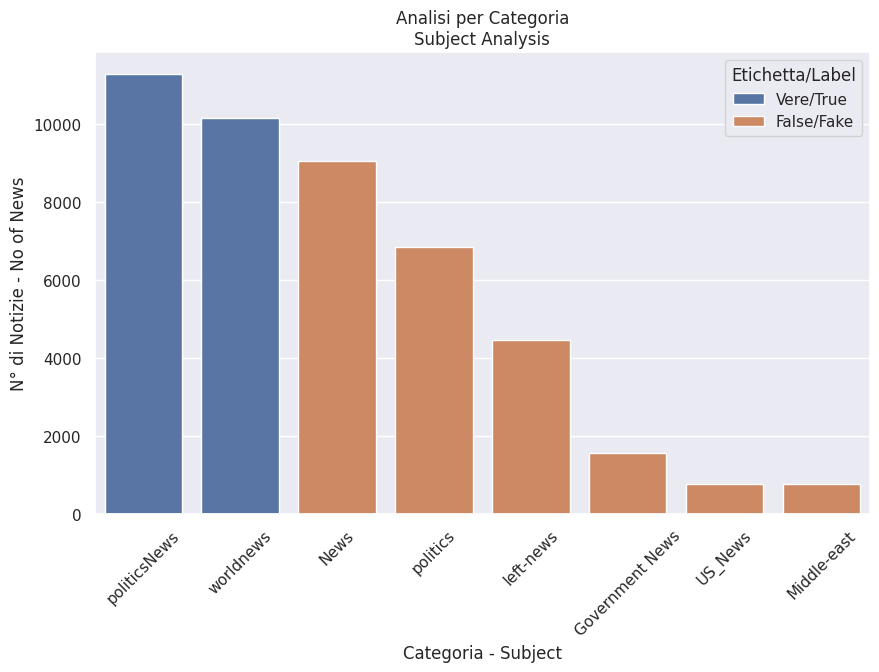

In [ ]:
# Creazione grafico a barre
# Create bar chart
sns.countplot(data=df, x="subject", hue="label", order=df.subject.value_counts().index)

plt.title("Analisi per Categoria\nSubject Analysis")
plt.xlabel("Categoria - Subject")
plt.ylabel("N° di Notizie - No of News")
plt.xticks(rotation=45)
plt.legend(title="Etichetta/Label", labels=["Vere/True", "False/Fake"])

plt.show()

**Commento - _Comment_**

Le categorie dipendono fortemente dalle fonti e non sono standardizzate tra notizie vere e notizie false.<br>
Dall'analisi emerge che le Notizie False sono maggiormente concentrate nelle categorie di notizie a carattere generale "News" e in quelle di natura politica "politics".

_The categories strongly depend on the data sources and are not standardized between true and fake news.<br>
From the analysis, it emerges that Fake News are mainly concentrated in general news categories "News" and politically related categories "politics"._

###**1.3 Analisi degli Argomenti (Notizie False) / _Topic Analysis (Fake News)_**

In [ ]:
# Topic modeling

documents = content_union(df[df["label"] == FAKE_LABEL], "title", "text")

def sent_to_words(items):
  for item in items:
    yield(simple_preprocess(item, deacc=True))

def remove_stopwords(texts):
  return [[word for word in words if word not in en_stopwords and len(word) >= 3]
          for words in texts]

data_words = list(sent_to_words(documents))
data_words = remove_stopwords(data_words)

id2word = Dictionary(data_words)

corpus = [id2word.doc2bow(text) for text in data_words]

lda_model = LdaMulticore(corpus=corpus, id2word=id2word, num_topics=5, passes=10,
                         random_state=SEED, workers=2, chunksize=2000)

print("Argomenti estratti (15 parole)\nExtracted Topics (15 words)\n")
for topic_id, words in lda_model.print_topics(num_words=15):
  print(f"Topic {topic_id}:")
  print(words)
  print("="*100)

Argomenti estratti (15 parole)
Extracted Topics (15 words)

Topic 0:
0.007*"said" + 0.005*"state" + 0.004*"people" + 0.004*"law" + 0.004*"police" + 0.004*"would" + 0.004*"one" + 0.004*"government" + 0.003*"federal" + 0.003*"year" + 0.003*"gun" + 0.003*"obama" + 0.003*"muslim" + 0.003*"court" + 0.003*"states"
Topic 1:
0.041*"trump" + 0.010*"president" + 0.009*"donald" + 0.007*"people" + 0.006*"would" + 0.006*"said" + 0.006*"obama" + 0.005*"one" + 0.005*"like" + 0.005*"republican" + 0.004*"even" + 0.004*"image" + 0.004*"republicans" + 0.004*"featured" + 0.004*"via"
Topic 2:
0.019*"clinton" + 0.013*"hillary" + 0.012*"trump" + 0.007*"said" + 0.006*"campaign" + 0.006*"fbi" + 0.006*"president" + 0.005*"russia" + 0.005*"election" + 0.005*"state" + 0.005*"house" + 0.005*"russian" + 0.004*"former" + 0.004*"investigation" + 0.004*"news"
Topic 3:
0.007*"video" + 0.007*"twitter" + 0.006*"black" + 0.006*"said" + 0.005*"people" + 0.005*"trump" + 0.005*"com" + 0.005*"one" + 0.004*"white" + 0.004*"lik

**Commento - _Comment_**

L'analisi degli argomenti mostra che le fake news sono prevalentemente associate a temi politici e geopolitici, con particolare riferimento a figure politiche statunitensi, campagne elettorali e questioni internazionali.

_The topic modeling analysis show that the fake news are mainly associated with political and geopolitical themes, with particular reference to U.S. political figures, electoral campaigns and international issues._

###**1.4 Analisi dei Titoli / _Titles Analysis_**

**Termini più usati / _Most frequently used terms_**

In [ ]:
# Titoli puliti: separazione falsi da veri
# Cleaned titles: split in to fake and true
fake_titles = df_cleaned.loc[df_cleaned["label"] == FAKE_LABEL, "title_cleaned"]
true_titles = df_cleaned.loc[df_cleaned["label"] == TRUE_LABEL, "title_cleaned"]

# Vettorizzazione in bigrammi
# Vectorizer to bigrams
count_vec = CountVectorizer(ngram_range=(2, 2), min_df=5, max_df=0.9)

X_fake = count_vec.fit_transform(fake_titles)
X_true = count_vec.transform(true_titles)

terms = count_vec.get_feature_names_out()

# Somma conteggi per ogni bigramma
# Sum counts for each bigrams
fake_counts = np.array(X_fake.sum(axis=0))
true_counts = np.array(X_true.sum(axis=0))

# Serie per ordinare e visualizzare facilmente
# Series to sort and display easly
fake_freq = pd.Series(fake_counts.reshape(-1), index=terms).sort_values(ascending=False)
true_freq = pd.Series(true_counts.reshape(-1), index=terms).sort_values(ascending=False)

# Rapporto dei bigrammi titoli falsi vs titoli veri
# Fake vs True ratio
ratio = (fake_freq/(true_freq.reindex(index=fake_freq.index))).round(2)

# Comparazione risultati
# Results comparison
comparison = pd.concat([fake_freq.head(20).rename("fake_count"),
                        true_freq.reindex(fake_freq.index).head(20).rename("true_count"),
                        ratio.head(20).rename("ratio")], axis=1)

print("Primi 20 termini (bigrammi) nei titoli di Notizie False: frequenza e confronto con Notizie Vere\n"+
      f"First 20 terms (bigrams) in Fake News titles: frequency and comparison with True News titles\n")
print("Nota: il ratio indica quante volte un termine compare nei titoli delle notizie false rispetto alle notizie vere\n"+
      f"Note: the ratio indicates how many times a term appears in fake news title compared to true news")
comparison

Primi 20 termini (bigrammi) nei titoli di Notizie False: frequenza e confronto con Notizie Vere
First 20 terms (bigrams) in Fake News titles: frequency and comparison with True News titles

Nota: il ratio indica quante volte un termine compare nei titoli delle notizie false rispetto alle notizie vere
Note: the ratio indicates how many times a term appears in fake news title compared to true news


,fake_count,true_count,ratio
donald trump,803,55,14.60
president trump,497,19,26.16
hillary clinton,411,44,9.34
trump supporter,402,7,57.43
white house,345,786,0.44
fox news,313,30,10.43
trump video,286,2,143.00
bernie sander,215,9,23.89
ted cruz,213,10,21.30
illegal alien,210,0,inf


**Commento - _Comment_**

Dalla tabella emerge che alcuni termini (bigrammi) compaiono con una frequenza significativamente maggiore nei titoli delle notizie false rispetto a quelli delle notizie vere. In particolare riferimenti a figure politiche, temi sensazionalistici o controversi mostrano valori di ratio elevati, indicando una forte associazione con le fake news.<br>
La presenza di ratio infinito evidenzia che alcuni termini compaiono esclusivamente in titoli di notizie false, suggerendo pattern potenzialmente utili per la classificazione.

_From the table it emerges that several terms (bigrams) appear with a significantly higher frequency in fake news titles compared to true news titles. In particular, references to political figures and sensational or controversial topics show high ratio values, indicating a strong association with fake news.<br>
The presence of infinite ratio values further highlights terms that appear exclusively in fake news titles, suggesting patterns that may be useful for classification purposes._

**Lunghezza dei titoli e conteggio parole / _Titles length and words count_**

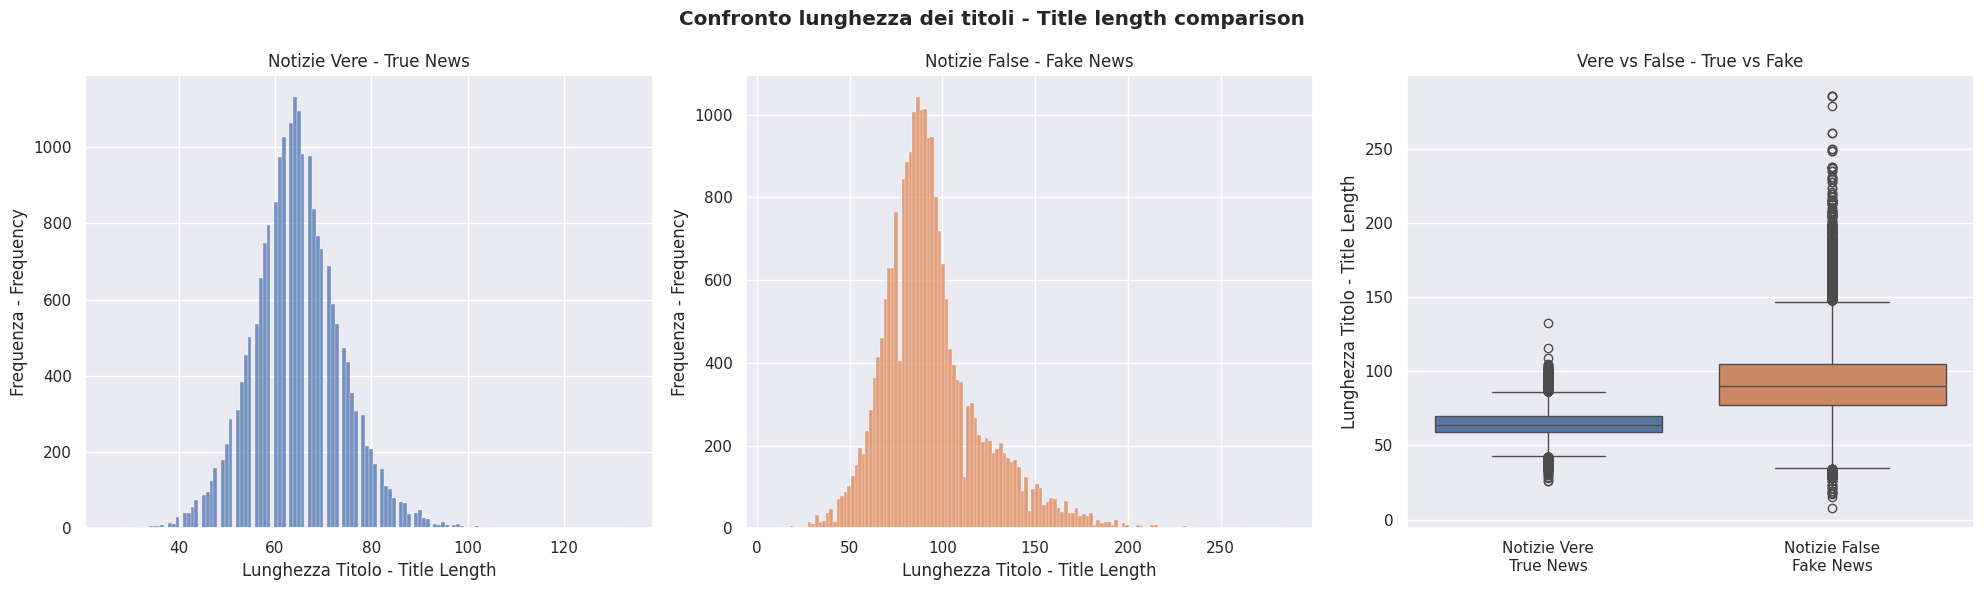

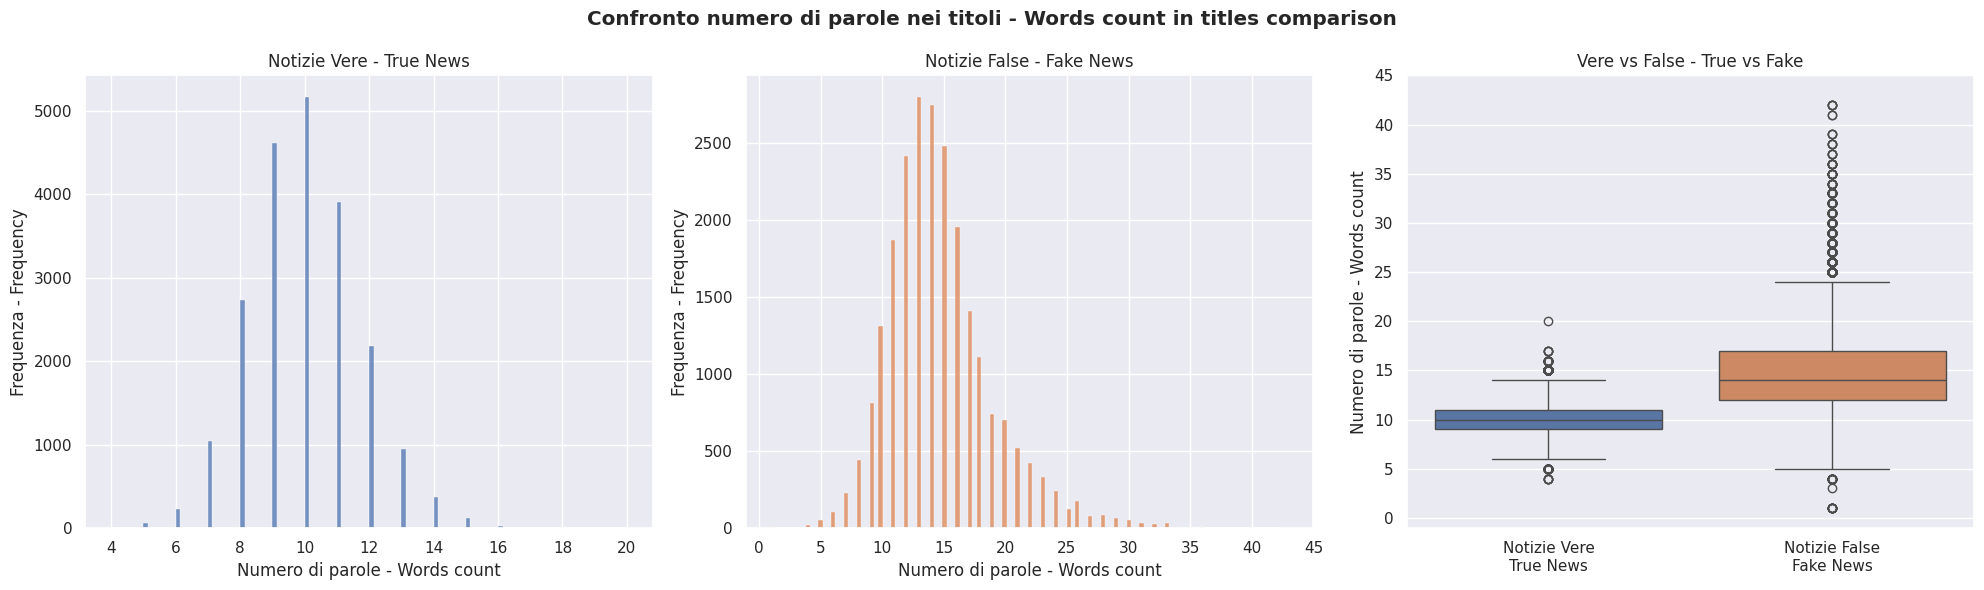

In [ ]:
# Misurazione lunghezza titoli originali
# Original titles lenght measurement
df_cleaned["title_length"] = df["title"].apply(len)

# Separazione lunghezze titoli: false da vere
# Split length titles: fake and true
fake_len_titles = df_cleaned.loc[df_cleaned["label"] == FAKE_LABEL, "title_length"]
true_len_titles = df_cleaned.loc[df_cleaned["label"] == TRUE_LABEL, "title_length"]

#Impostazione figura
# Figure setting
plt.figure(figsize=(20, 6))
palette = sns.color_palette("deep")

# Istogrammi e boxplot lunghezza
# Histogram and boxplot for lenght
plt.subplot(1, 3, 1)
sns.histplot(true_len_titles, color=palette[0])
plt.title("Notizie Vere - True News")
plt.xlabel("Lunghezza Titolo - Title Length")
plt.ylabel("Frequenza - Frequency")

plt.subplot(1, 3, 2)
sns.histplot(fake_len_titles, color=palette[1])
plt.title("Notizie False - Fake News")
plt.xlabel("Lunghezza Titolo - Title Length")
plt.ylabel("Frequenza - Frequency")


plt.subplot(1, 3, 3)
sns.boxplot(x="label", y="title_length", data=df_cleaned, hue="label",
            palette=[palette[0], palette[1]], legend=False)
plt.title("Vere vs False - True vs Fake")
plt.xlabel("")
plt.ylabel("Lunghezza Titolo - Title Length")
plt.xticks(ticks=[0, 1], labels=["Notizie Vere\nTrue News", "Notizie False\nFake News"])

plt.suptitle("Confronto lunghezza dei titoli - Title length comparison", fontweight="bold")

plt.tight_layout()
plt.show()


#Impostazione figura
# Figure setting
plt.figure(figsize=(20, 6))

# Conteggio parole nei titoli originali
# Word count in original titles
df_cleaned["title_words_count"] = df["title"].apply(lambda x: len(x.split()))

# Separazione numero di parole nei titoli: false da vere
# Split words count in titles: fake and true
fake_words_titles = df_cleaned.loc[df_cleaned["label"] == FAKE_LABEL, "title_words_count"]
true_words_titles = df_cleaned.loc[df_cleaned["label"] == TRUE_LABEL, "title_words_count"]

# Istogrammi e boxplot numero di parole
# Histogram and boxplot for words count
plt.subplot(1, 3, 1)
sns.histplot(true_words_titles, color=palette[0])
plt.title("Notizie Vere - True News")
plt.xlabel("Numero di parole - Words count")
plt.ylabel("Frequenza - Frequency")

plt.subplot(1, 3, 2)
sns.histplot(fake_words_titles, color=palette[1])
plt.title("Notizie False - Fake News")
plt.xlabel("Numero di parole - Words count")
plt.ylabel("Frequenza - Frequency")
plt.xticks(range(0, 50, 5))

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x="label", y="title_words_count", data=df_cleaned, hue="label",
            palette=[palette[0], palette[1]], legend=False)
plt.title("Vere vs False - True vs Fake")
plt.xlabel("")
plt.ylabel("Numero di parole - Words count")
plt.xticks(ticks=[0, 1], labels=["Notizie Vere\nTrue News", "Notizie False\nFake News"])
plt.yticks(range(0, 50, 5))

plt.suptitle("Confronto numero di parole nei titoli - Words count in titles comparison", fontweight="bold")

plt.tight_layout()
plt.show()

**Commento - _Comment_**

Dai grafici emerge una differenza chiara: le notizie false tendono ad avere titoli mediamente più lunghi, con un utilizzo maggiore di parole, rispetto alle notizie vere.<br>
Questa evidenza suggerisce che la lunghezza dei titoli può rappresentare una caratteristica utile per distinguere notizie false da quelle vere.

_The charts highlight a clear difference: fake news tend to have longer titles on average, with a higher number of words compared to true news.<br>
This evidence suggests that title lengrh may rappresent a useful feature for distinguing fake news from true news._

**Uso di parole maiuscole nei titoli / _Uppercase words usage in titles_**

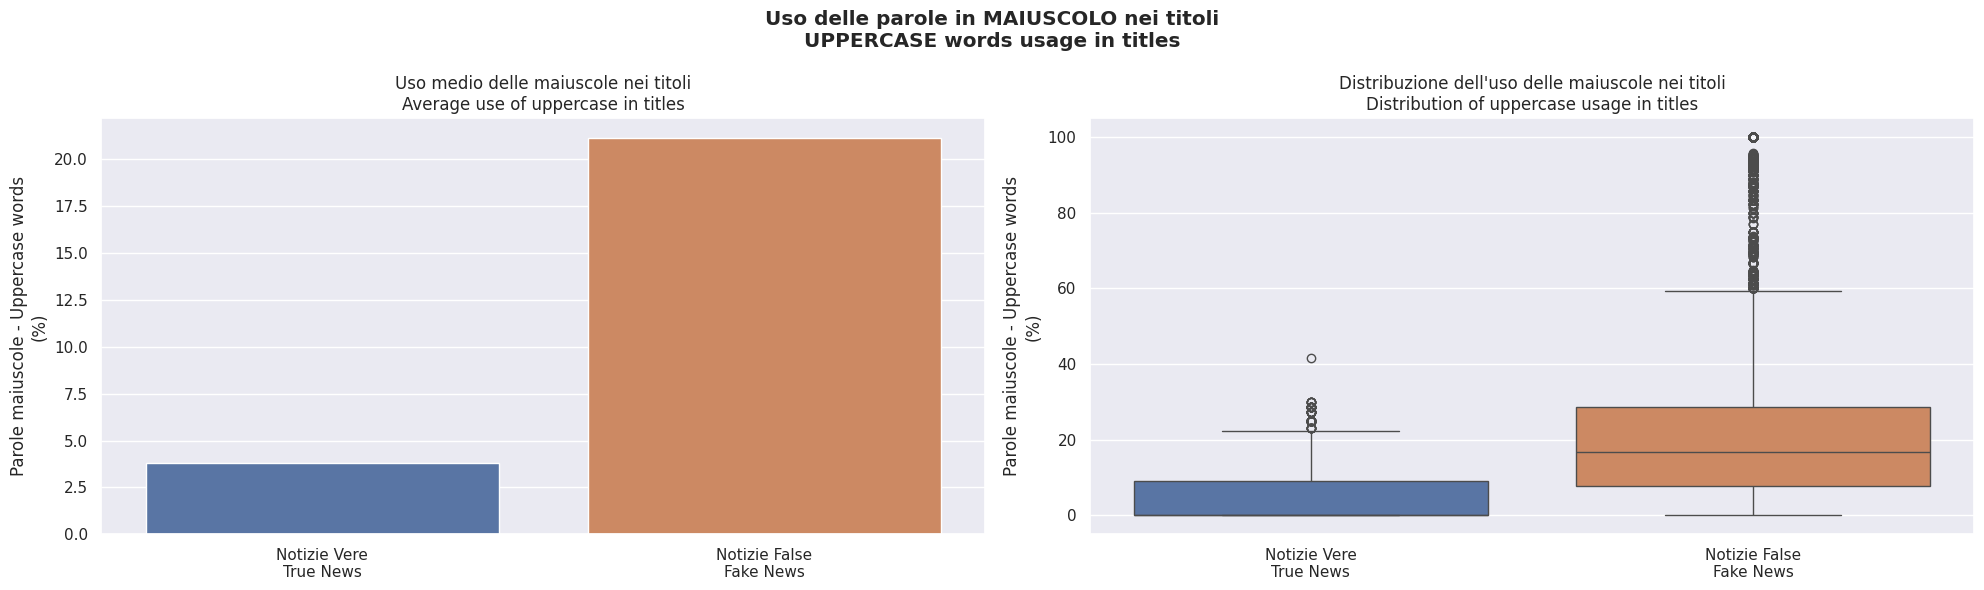

Valore medio della percentuale di parole in maiuscolo nei titoli
Average percentage of uppercase words in news titles
- Notizie vere / True news:  3.78%
- Notizie false / Fake news:  21.13%


In [ ]:
# Calcolo del rapporto di parole maiuscole nei titoli originali
# Ratio calculation of uppercase words in original titles
df_cleaned["title_uppercase_ratio(%)"] = df["title"].apply(uppercase_ratio)

# Separazione tra false e vere
# Split fake and true
fake_upper_ratio = df_cleaned.loc[df_cleaned["label"] == FAKE_LABEL, "title_uppercase_ratio(%)"]
true_upper_ratio = df_cleaned.loc[df_cleaned["label"] == TRUE_LABEL, "title_uppercase_ratio(%)"]

#Impostazione figura
# Figure setting
plt.figure(figsize=(20, 6))

# Grafico a barre: media uso parole maiuscole
# Bar chart: average uppercase words usage
plt.subplot(1, 2, 1)
sns.barplot(data=df_cleaned, x="label", y="title_uppercase_ratio(%)", estimator="mean",
            hue="label", palette=[palette[0], palette[1]], errorbar=None, legend=False)
plt.title("Uso medio delle maiuscole nei titoli\nAverage use of uppercase in titles")
plt.xlabel("")
plt.ylabel("Parole maiuscole - Uppercase words\n(%)")
plt.xticks(ticks=[0, 1], labels=["Notizie Vere\nTrue News", "Notizie False\nFake News"])

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x="label", y="title_uppercase_ratio(%)", data=df_cleaned, hue="label",
            palette=[palette[0], palette[1]], legend=False)
plt.title("Distribuzione dell'uso delle maiuscole nei titoli\nDistribution of uppercase usage in titles")
plt.xlabel("")
plt.ylabel("Parole maiuscole - Uppercase words\n(%)")
plt.xticks(ticks=[0, 1], labels=["Notizie Vere\nTrue News", "Notizie False\nFake News"])

plt.suptitle("Uso delle parole in MAIUSCOLO nei titoli\nUPPERCASE words usage in titles", fontweight="bold")

plt.tight_layout()
plt.show()

print("Valore medio della percentuale di parole in maiuscolo nei titoli\n"+
      f"Average percentage of uppercase words in news titles")
print(f"- Notizie vere / True news: {true_upper_ratio.mean(): .2f}%")
print(f"- Notizie false / Fake news: {fake_upper_ratio.mean(): .2f}%")

**Commento - _Comment_:**

Dall'analisi emerge una differenza marcata nell'uso delle maiuscole all'interno dei titoli: in media, solo il 3.78% delle parole nei titoli delle notizie vere è scritto in maiuscolo, mentre nelle notizie false la percentuale sale al 21.13%.<br>
Questo dato evidenzia come le notizie false tendano ad utilizzare le maiuscole come strumento di enfasi visiva, aumentando l'impatto immediato del titolo e rendendolo più aggressivo e sensazionalistico.

_From the analysis, a marked difference in the use of uppercase letters in titles emerges: on average, only 3.78% of the words in true news titles are written in uppercase, while in fake news titles this percentage rises to 21.13%.<br>
This result highlights how fake news tend to use uppercase letters as a visual emphasis strategy, increasing the immediate impact on the title and makinkg it more aggressive and sensationalistic._

##**2. ADDESTRAMENTO DEL MODELLO / _MODEL TRAINING_**

Vengono addestrati tre modelli di classificazione, che saranno successivamente confrontati per valutarne le prestazioni e individuare il modello migliore.

_Three classification models are trained and subsequently compared to evaluate their performance and identify the best-performing model._

**Preparazione dei dati per l'addestramento / _Data preparation for model training_**

In [ ]:
# Selezione delle feature (X) e del target (y)
# Select feature (X) and target (y)
X = df_cleaned["content"]
y = df_cleaned["label"]

# Suddivisione in set di training e di test
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# Vettorizzazione
# Vectorization
tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.9)
X_train_vec = tfidf_vec.fit_transform(X_train)
X_test_vec = tfidf_vec.transform(X_test)

In [ ]:
X_train.shape, X_test.shape

((35918,), (8980,))

**Modello di Regressione Logistica / _Logistic Regression Model_**

In [ ]:
# Inizialiazzazione del modello
# Model initialization
lr = LogisticRegression(max_iter=1000, random_state=SEED)

# Addestramento del modello
# Model training
lr.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**Modello Multinomial Naive Bayes / _Multinomial Naive Bayes Model_**

In [ ]:
# Inizialiazzazione del modello
# Model initialization
mnb = MultinomialNB()

# Addestramento del modello
# Model training
mnb.fit(X_train_vec, y_train)

MultinomialNB()

**Modello Multi Layer Perceptron / _Multi Layer Perceptron Model_**

In [ ]:
# Inizialiazzazione del modello
# Model initialization
mlp = MLPClassifier(activation="logistic", solver="adam", hidden_layer_sizes=(100,),
                    max_iter=20, tol=0.01, random_state=SEED, verbose=True)

# Addestramento del modello
# Model training
mlp.fit(X_train_vec, y_train)

Iteration 1, loss = 0.48260507
Iteration 2, loss = 0.15291321
Iteration 3, loss = 0.07418846
Iteration 4, loss = 0.04827104
Iteration 5, loss = 0.03639439
Iteration 6, loss = 0.02986456
Iteration 7, loss = 0.02573378
Iteration 8, loss = 0.02279847
Iteration 9, loss = 0.02056654
Iteration 10, loss = 0.01877721
Iteration 11, loss = 0.01728001
Iteration 12, loss = 0.01599678
Iteration 13, loss = 0.01490049
Iteration 14, loss = 0.01392516
Iteration 15, loss = 0.01309299
Iteration 16, loss = 0.01230086
Training loss did not improve more than tol=0.010000 for 10 consecutive epochs. Stopping.


MLPClassifier(activation='logistic', max_iter=20, random_state=42, tol=0.01,
              verbose=True)

##**3. VALIDAZIONE E OTTIMIZZAZIONE / _VALIDATION AND OPTIMIZATION_**

###**3.1 Validazione dei modelli / _Model validation_**

**Modello di Regressione Logistica / _Logistic Regression Model_**

Report metriche modello di Regressione Logistica
Metrics report for Logistic Regression
              precision    recall  f1-score   support

   Vere/True       0.99      0.99      0.99      4284
  False/Fake       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



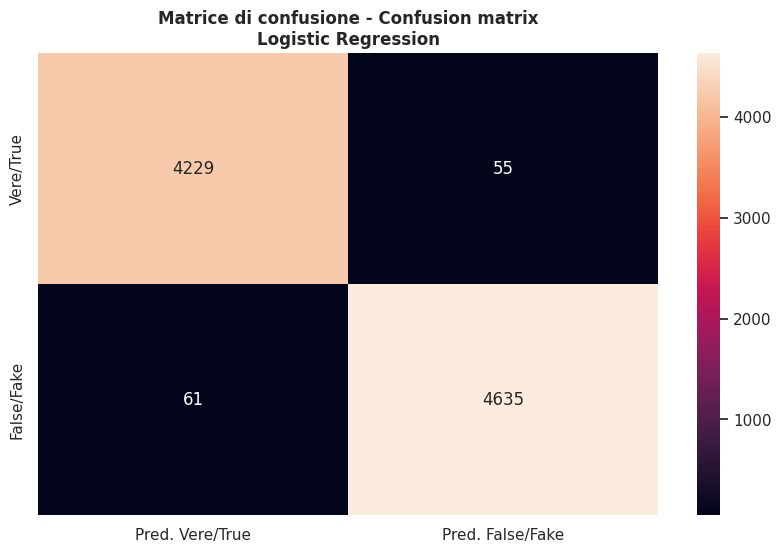

In [ ]:
# Predizione sul set di test
# Predict on test set
y_pred_lr = lr.predict(X_test_vec)

# Calcolo delle metriche
# Metrics calculation
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Report completo
# Complete report
print("Report metriche modello di Regressione Logistica\nMetrics report for Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=["Vere/True", "False/Fake"]))

# Matrice di confusione
# Confusion matrix
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

**Modello Multinomial Naive Bayes / _Multinomial Naive Bayes Model_**

Report metriche modello di Regressione Logistica
Metrics report for Logistic Regression
              precision    recall  f1-score   support

   Vere/True       0.96      0.94      0.95      4284
  False/Fake       0.95      0.97      0.96      4696

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



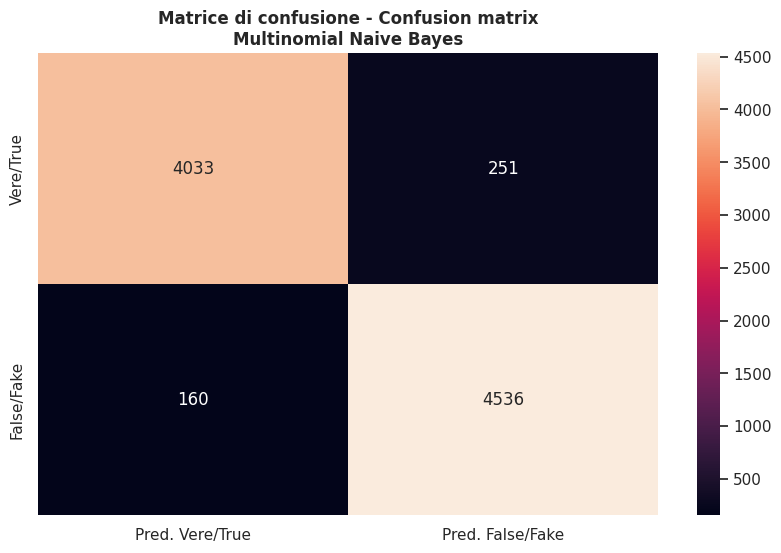

In [ ]:
# Predizione sul set di test
# Predict on test set
y_pred_mnb = mnb.predict(X_test_vec)

# Calcolo delle metriche
# Metrics calculation
acc_mnb = accuracy_score(y_test, y_pred_mnb)
prec_mnb = precision_score(y_test, y_pred_mnb)
rec_mnb = recall_score(y_test, y_pred_mnb)
f1_mnb = f1_score(y_test, y_pred_mnb)

# Report completo
# Complete report
print("Report metriche modello di Multinomial Naive Bayes\nMetrics report for Multinomial Naive Bayes")
print(classification_report(y_test, y_pred_mnb, target_names=["Vere/True", "False/Fake"]))

# Matrice di confusione
# Confusion matrix
plot_confusion_matrix(y_test, y_pred_mnb, "Multinomial Naive Bayes")

**Modello Multi Layer Perceptron / _Multi Layer Perceptron Model_**

Report metriche modello di Regressione Logistica
Metrics report for Logistic Regression
              precision    recall  f1-score   support

   Vere/True       0.99      0.99      0.99      4284
  False/Fake       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



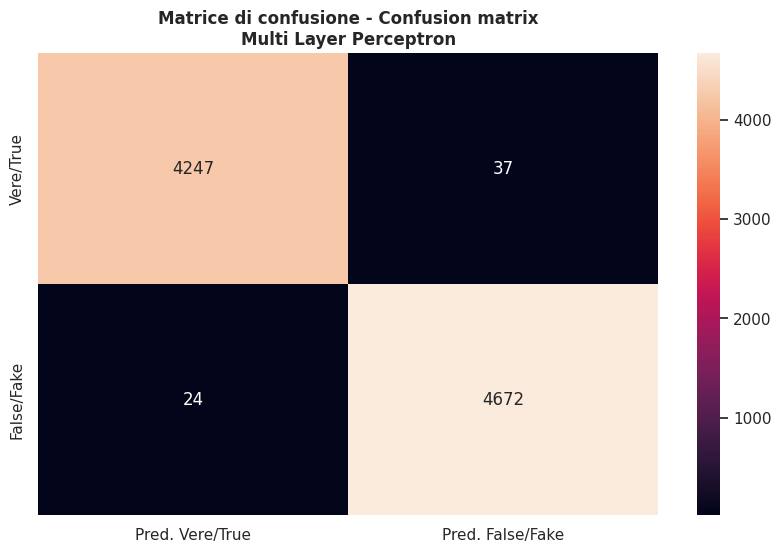

In [ ]:
# Predizione sul set di test
# Predict on test set
y_pred_mlp = mlp.predict(X_test_vec)

# Calcolo delle metriche
# Metrics calculation
acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp)
rec_mlp = recall_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)

# Report completo
# Complete report
print("Report metriche modello di Multi Layer Perceptron\nMetrics report for Multi Layer Perceptron")
print(classification_report(y_test, y_pred_mlp, target_names=["Vere/True", "False/Fake"]))

# Matrice di confusione
# Confusion matrix
plot_confusion_matrix(y_test, y_pred_mlp, "Multi Layer Perceptron")

###**3.2 Verifica della presenza di overfitting tramite Log Loss / _Overfitting assessment using Log Loss_**

In [ ]:
models = {"Logistic Regression": lr, "Multinomial Naive Bayes": mnb, "Multi Layer Perceptron": mlp}

for name, model in models.items():
  y_train_proba = model.predict_proba(X_train_vec)
  y_test_proba = model.predict_proba(X_test_vec)

  train_logloss = log_loss(y_train, y_train_proba)
  test_logloss = log_loss(y_test, y_test_proba)

  print(f"{name}")
  print(f"Log Loss train: {train_logloss:.4f}")
  print(f"Log Loss test: {test_logloss:.4f}")
  print(f"Differenza/Difference (train - test): {train_logloss - test_logloss:.4f}")
  print("="*100)

Logistic Regression
Log Loss train: 0.0802
Log Loss test: 0.0890
Differenza/Difference (train - test): -0.0088
Multinomial Naive Bayes
Log Loss train: 0.0992
Log Loss test: 0.1265
Differenza/Difference (train - test): -0.0273
Multi Layer Perceptron
Log Loss train: 0.0032
Log Loss test: 0.0225
Differenza/Difference (train - test): -0.0194


**Commento - _Comment_**

Dall'analisi della log loss emerge che tutti e tre i modelli mostrano una buona capacità di generalizzazione: valori molto bassi e molto simili tra set di addestramento e di test. Nessuno dei modelli presenta quindi una tendenza all'overfitting.

_From the log loss analysis, it emerges that all three models show a good generalization capabilty, with very low and very similar values between the traning and the test sets. Therefore, none of the models exhibits a tendency to overfitting._

###**3.3 Confronto dei modelli / _Models comparison_**

In [ ]:
# Creazione DF per comparazione
# Create comparison DF
results_df = pd.DataFrame({"Model": ["Logistic Regression", "Multinomial Naive Bayes", "Multi Layer Perceptron"],
                           "Accuracy": [acc_lr, acc_mnb, acc_mlp],
                           "Precision": [prec_lr, prec_mnb, prec_mlp],
                           "Recall": [rec_lr, rec_mnb, rec_mlp],
                           "F1 Score": [f1_lr, f1_mnb, f1_mlp]})

results_df = results_df.round(4)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9871,0.9883,0.9870,0.9876
1,Multinomial Naive Bayes,0.9542,0.9476,0.9659,0.9567
2,Multi Layer Perceptron,0.9932,0.9921,0.9949,0.9935


**Commento - _Comment_**

Sebbene il modello Multi Layer Perceptron (MLP) mostri metriche leggermente migliori, il modello di **Regressione Logistica** garantisce prestazioni molto elevate con una complessità computazionale nettamente inferiore e una maggiore interpretabilità. Per questi motivi viene **scelto come modello finale**.

_Although the Multi Layer Perceptron (MLP) model achieves slightly higher performance metrics, **Logistic Regression** model provides very high predictive performance with significantly lower computational complexity and greater interpretability. For these reasons, it **was selceted as the final model**._

###**3.4 Ottimizzazione del modello / _Model optimization_**

L'ottimizzazione del modello viene effettuata introducendo alcune caratteristiche emerse dall'analisi dei titoli, come la lunghezza del titolo e l'uso di lettere maiuscole.<br>
Queste informazioni, affiancate al contenuto testuale della notizia, possono permettere al modello di sfruttare anche aspetti strutturali e stilistici del titolo, aggiungendo la capacità di riconoscere notizie false già a partire dalle modalità con cui vengono presentate.

_The model optimization is carried out by integrating come features identified during the analysis of the titles, such as title length and the use of uppercase letters.<br>
These features, combined with the textual content of the news, can allow the model to also exploit structural and stilistic aspects of the title, adding the ability to recognize fake news already from the way they are presented._

Report metriche modello di Regressione Logistica (set completo)
Metrics report for Logistic Regression (complete set)
              precision    recall  f1-score   support

   Vere/True       0.98      1.00      0.99      4284
  False/Fake       1.00      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



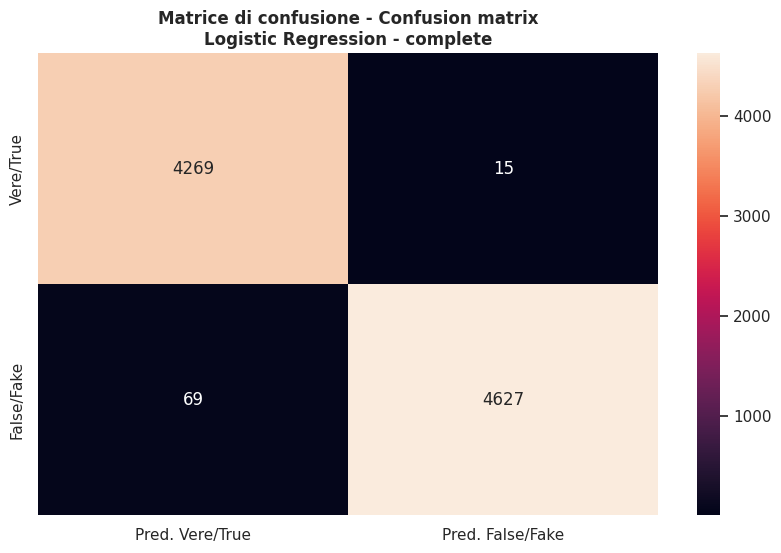

In [ ]:
# Selezione delle feature dei titoli e allineamento con i set di training e test
# Select title features and align with training and test sets
title_features = ["title_length",	"title_words_count",	"title_uppercase_ratio(%)"]
X_train_title = df_cleaned.loc[X_train.index, title_features]
X_test_title = df_cleaned.loc[X_test.index, title_features]

# Standardizzazione
# standardization
ss = StandardScaler()
X_train_title_scaled = ss.fit_transform(X_train_title)
X_test_title_scaled = ss.transform(X_test_title)

# Coversione array in matrici sparse
# Convert array in sparce matrix
X_train_title_sparse = csr_matrix(X_train_title_scaled)
X_test_title_sparse = csr_matrix(X_test_title_scaled)

# Unione in unico set
# Join into a single set
X_train_complete = hstack([X_train_vec, X_train_title_sparse])
X_test_complete = hstack([X_test_vec, X_test_title_sparse])

# Addestramento del modello LR
# LR model training
lr_complete = LogisticRegression(max_iter=1000, random_state=SEED)
lr_complete.fit(X_train_complete, y_train)

# Predizione sul set di test
# Predict on test set
y_pred_lr_complete = lr_complete.predict(X_test_complete)

# Calcolo delle metriche
# Metrics calculation
acc_lr_complete = accuracy_score(y_test, y_pred_lr_complete)
prec_lr_complete = precision_score(y_test, y_pred_lr_complete)
rec_lr_complete = recall_score(y_test, y_pred_lr_complete)
f1_lr_complete = f1_score(y_test, y_pred_lr_complete)

# Report completo
# Complete report
print("Report metriche modello di Regressione Logistica (set completo)\nMetrics report for Logistic Regression (complete set)")
print(classification_report(y_test, y_pred_lr_complete, target_names=["Vere/True", "False/Fake"]))

# Matrice di confusione
# Confusion matrix
plot_confusion_matrix(y_test, y_pred_lr_complete, "Logistic Regression - complete")

**Verifica della presenza di overfitting tramite Log Loss / _Overfitting assessment using Log Loss_**

In [ ]:
y_train_complete_proba = lr_complete.predict_proba(X_train_complete)
y_test_complete_proba = lr_complete.predict_proba(X_test_complete)
train_complete_logloss = log_loss(y_train, y_train_complete_proba)
test_complete_logloss = log_loss(y_test, y_test_complete_proba)
print(f"Logistic Regression (complete set)")
print(f"Log Loss train: {train_complete_logloss:.4f}")
print(f"Log Loss test: {test_complete_logloss:.4f}")
print(f"Differenza/Difference (train - test): {train_complete_logloss - test_complete_logloss:.4f}")

Logistic Regression (complete set)
Log Loss train: 0.0472
Log Loss test: 0.0538
Differenza/Difference (train - test): -0.0066


**Commento - _Comment_**

Anche dopo l'integrazione delle caratteristiche dei titoli, la log loss rimane molto bassa e molto simile tra il set di addestramento e il set di test. Questo indica che il modello mantiene una buona capacità di generalizzazione e non mostra evidenze di overfitting.

_Even after integrating the title features, the log loss remains very low and very similar between the training and the test sets. This indicates that the model maintains good generalization capabilty and does not show evidence of overfitting._

**Confronto tra modello base e modello completo / _Comparison between baselin model and complete model_**

In [ ]:
# Creazione DF per comparazione
# Create comparison DF
results_lr_models = pd.DataFrame({"Model": ["Logistic Regression Baseline", "Logistic Regression Complete"],
                           "Accuracy": [acc_lr, acc_lr_complete],
                           "Precision": [prec_lr, prec_lr_complete],
                           "Recall": [rec_lr, rec_lr_complete],
                           "F1 Score": [f1_lr, f1_lr_complete]})

results_lr_models = results_lr_models.round(4)
results_lr_models

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression Baseline,0.9871,0.9883,0.9870,0.9876
1,Logistic Regression Complete,0.9906,0.9968,0.9853,0.9910


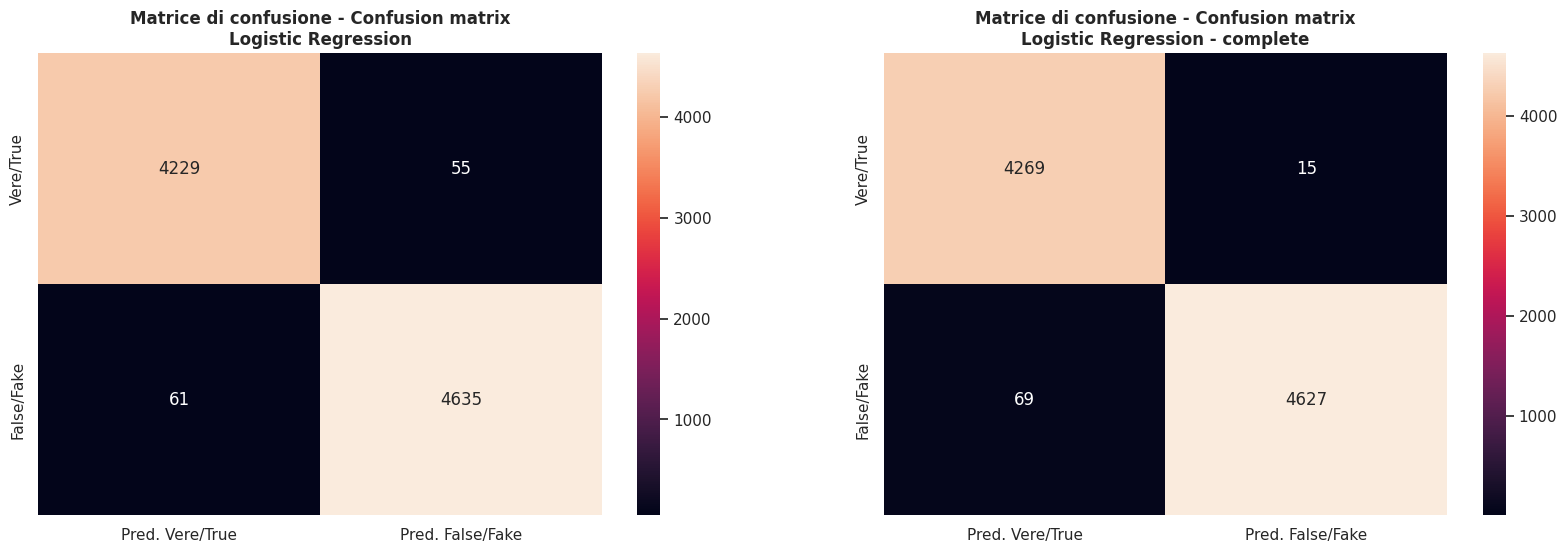

In [ ]:
# Confronto matrici di confusione
# Confusion matrix comparison
plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

plt.subplot(1, 2, 2)
plot_confusion_matrix(y_test, y_pred_lr_complete, "Logistic Regression - complete")

**Commento - _Comment_**

Il confronto tra il modello base e il modello completo evidenzia che l'integrazione delle caratteristiche estratte dai titoli comporta un lieve aumento della precision (maggiore affidabilità delle notizie classificate come false), a fronte di una leggera riduzione della recall (minore capacità di intercettare tutte le notizie false presenti).<br>
Nel complesso, il valore di F1-score risulta solo marginalmente superiore nel modello completo, indicando un miglior equilibrio aggregato tra precision e recall.<br>
Tuttavia, l'analisi della matrice di confusione mostra che il modello completo tende a classificare un numero maggiore di notizie false come vere rispetto al modello base.<br>
Poiché l'obiettivo principale è il contrasto alla disinformazione e la riduzione del rischio che contenuti non affidabili vengano presentati come veri, questo tipo di errore risulta più critico rispetto ai falsi positivi (notizie vere classificate come false).<br>
Per questo motivo, nonostante metriche aggregate leggermente inferiori, il modello **Logistic Regression Base viene selezionato per l'implementazione finale**, in quanto adotta un approccio più conservativo e maggiormente coerente con le finalità del sistema.

_The comparison between the baseline model and the complete model shows that integrating features extracted from the titles leads to a slight inrease in precision (greater reliability of the news classified as fake), at the cost of a slight reduction in recall (lower ability to intercept all fake news present).<br>
Overall, the F1-score is only marginally higher for the complete model, indicating a slightly better aggregated balance between precision and recall. However, the analysis of the confusion matrix shows that the comlete model tends to classify a higher number of fake news items as true compared to a baseline model.<br>
Since the primary objective is to combat disinformation and reduce the risk that unreliable content is presented as true, this type of error is considered more critical than false positive (true news incorrectly cassified as fake).<br>
For this reason, despite slightly lower aggregated metrics, the **Baseline Logistic Regression model is selcted for the final implementation**, as it adopts a more conservative approach and is more consistent with the goals of the system._

##**4. ESPORTAZIONE DEL MODELLO / _MODEL EXPORT_**

In [ ]:
MODEL_FILE_NAME = "lr_baseline_model_fake_news.plk"

model_bundle = {"model": lr, "vectorizer": tfidf_vec}

with open(MODEL_FILE_NAME, "wb") as f:
  pickle.dump(model_bundle, f)